In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import sklearn
import umap.umap_ as umap
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook
# for classifcator 
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay, recall_score, precision_score



In [2]:
path = '/home/rfit/Telescope_Array/phd_work/src/BERT/augmentation_research/info_Transfoemr_MMD_0.05_KL_0.01ITERATE'
all_emb = {}
for part in os.listdir(path):
    all_emb[part] = {}
    for f in os.listdir(path + '/' + part):
        file = path + '/' + part + '/' + f
        n = f.split('_')[-1].replace('.npy', '')
        n=int(n)
        all_emb[part][n] = np.load(file)

In [3]:
print(all_emb.keys())
print(all_emb['proton'].keys())

print(all_emb['photon'].keys())
print(all_emb['proton'][0].shape)

dict_keys(['proton', 'photon'])
dict_keys([14, 5, 15, 11, 19, 3, 16, 17, 2, 0, 18, 12, 6, 1, 7, 10, 20, 8, 4, 13, 9])
dict_keys([14, 5, 15, 11, 19, 3, 16, 17, 2, 0, 18, 12, 6, 1, 7, 10, 20, 8, 4, 13, 9])
(779042, 8)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ------------------- Определение модели -------------------
class ClassificationNN(nn.Module):
    """
    Трёхслойная полносвязная сеть для бинарной классификации.
    """
    def __init__(self, input_dim, latent_dim=32):
        """
        Args:
            input_dim (int): размер входного вектора признаков.
            latent_dim (int): размер скрытых слоёв (по умолчанию 32).
        """
        super(ClassificationNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, latent_dim)
        self.fc2 = nn.Linear(latent_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 1)  # один выход для бинарной классификации
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                     # логиты, без сигмоиды
        return x

# ------------------- Функция обучения -------------------
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    """
    Функция для обучения модели.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()  # включает сигмоиду
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # Обучение
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.view(-1, 1).float())  # BCEWithLogitsLoss ожидает форму (batch, 1)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            train_correct += (preds.view(-1) == labels).sum().item()
            train_total += labels.size(0)

        # Валидация
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels.view(-1, 1).float())

                val_loss += loss.item() * inputs.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).int()
                val_correct += (preds.view(-1) == labels).sum().item()
                val_total += labels.size(0)

        train_loss_epoch = train_loss / train_total
        val_loss_epoch = val_loss / val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss_epoch:.4f} Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss_epoch:.4f} Acc: {val_acc:.4f}\n")


In [ ]:
def calc_classification_metric_shift(proton_st: np.array, photon_st: np.array, ax: plt.Axes):
    """
    Функция для обучения и оценки нейросетевого классификатора на данных протонов и фотонов.
    
    Параметры:
        proton_st (np.array): массив признаков для протонов (каждая строка – объект)
        photon_st (np.array): массив признаков для фотонов
        ax (plt.Axes): объект осей для отображения confusion matrix
    
    Возвращает:
        f1_score_, recall, precision, ax, model
    """
    # 1. Подготовка данных
    X = np.vstack([proton_st, photon_st])
    y = np.array([0] * len(proton_st) + [1] * len(photon_st))
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # 2. Перевод в тензоры PyTorch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
    
    # 3. Создание DataLoader'ов
    batch_size = 1000
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # 4. Инициализация модели, функции потерь, оптимизатора
    input_dim = X.shape[1]
    model = ClassificationNN(input_dim=input_dim, latent_dim=32).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 5. Обучение
    num_epochs = 200
    best_val_loss = float('inf')
    patience = 20
    trigger = 0
    best_model_state = None
    
    for epoch in tqdm_notebook(range(num_epochs)):
        # Обучение
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.view(-1, 1).float())
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
        
        # Валидация на тестовой выборке
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels.view(-1, 1).float())
                val_loss += loss.item() * inputs.size(0)
        
        train_loss /= len(train_loader.dataset)
        val_loss /= len(test_loader.dataset)
        
        # Печать каждые 20 эпох
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print(f"Early stopping на эпохе {epoch+1}")
                break
    
    # Восстановление лучшей модели
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # 6. Оценка на тестовой выборке
    model.eval()
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
    
    y_test_np = y_test  # оригинальные метки из sklearn (numpy)
    
    # 7. Вывод отчёта и метрик
    print("\nClassification Report:")
    print(classification_report(y_test_np, all_preds, target_names=['proton', 'photon']))
    
    f1_score_ = f1_score(y_test_np, all_preds)
    recall = recall_score(y_test_np, all_preds)
    precision = precision_score(y_test_np, all_preds)
    
    # # 8. Визуализация confusion matrix на переданных осях
    # cm = confusion_matrix(y_test_np, all_preds)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['proton', 'photon'])
    # disp.plot(ax=ax, cmap='Blues', values_format='d')
    # ax.set_title('Confusion Matrix (Neural Network)')
    
    return f1_score_, recall, precision, ax, model
Classificators = []
F1_list = []
recall_list = []
precision_list = []
num_iter = len(all_emb['proton'].keys())
# num_iter = 1
# fig, axs = plt.subplots(num_iter,1, figsize=(5,6*num_iter), sharex=True)
for i in tqdm_notebook(range(1, num_iter)):
    proton_st = all_emb['proton'][i][:20000] - all_emb['proton'][0][:20000]
    photon_st = all_emb['photon'][i][:20000]- all_emb['photon'][0][:20000]
    ax = None#axs[i]
    f1_score_,recall, precision, ax, model  = calc_classification_metric_shift(proton_st, photon_st, ax)
    print(f'f1_score in iteration {i}: {f1_score_}')
    Classificators.append(model)
    F1_list.append(f1_score_)
    recall_list.append(recall)
    precision_list.append(precision)

/tmp/ipykernel_66193/456615566.py:133: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(1, num_iter)):


  0%|          | 0/20 [00:00<?, ?it/s]

cuda


/tmp/ipykernel_66193/456615566.py:49: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for epoch in tqdm_notebook(range(num_epochs)):


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 20/200 | Train Loss: 0.6296 | Val Loss: 0.6272
Epoch 40/200 | Train Loss: 0.6148 | Val Loss: 0.6171
Epoch 60/200 | Train Loss: 0.6060 | Val Loss: 0.6116
Epoch 80/200 | Train Loss: 0.5997 | Val Loss: 0.6079
Epoch 100/200 | Train Loss: 0.5954 | Val Loss: 0.6048
Epoch 120/200 | Train Loss: 0.5920 | Val Loss: 0.6045
Epoch 140/200 | Train Loss: 0.5887 | Val Loss: 0.6020
Epoch 160/200 | Train Loss: 0.5861 | Val Loss: 0.6014
Epoch 180/200 | Train Loss: 0.5842 | Val Loss: 0.6015
Early stopping на эпохе 182

Classification Report:
              precision    recall  f1-score   support

      proton       0.66      0.69      0.68      4000
      photon       0.68      0.65      0.66      4000

    accuracy                           0.67      8000
   macro avg       0.67      0.67      0.67      8000
weighted avg       0.67      0.67      0.67      8000

f1_score in iteration 1: 0.6610343061955966
cuda


/tmp/ipykernel_66193/456615566.py:49: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for epoch in tqdm_notebook(range(num_epochs)):


  0%|          | 0/200 [00:00<?, ?it/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f0b12ac77f0>>
Traceback (most recent call last):
  File "/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Epoch 20/200 | Train Loss: 0.6051 | Val Loss: 0.6047
Epoch 40/200 | Train Loss: 0.5914 | Val Loss: 0.5928
Epoch 60/200 | Train Loss: 0.5841 | Val Loss: 0.5876


In [ ]:
def calc_classification_metric_shift(proton_st: np.array, photon_st: np.array, ax: plt.Axes):
    X = np.vstack([proton_st, photon_st])
    y = np.array([0] * len(proton_st) + [1] * len(photon_st))
    # Разделение на тренировочную и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        stratify=y,
        random_state=42
    )

    # Создание и обучение CatBoost классификатора
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.1,
        depth=6,
        verbose=100,
        early_stopping_rounds=50,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        plot=True
    )

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # Оценка модели
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    # ax.text(0.5, 0.5, classification_report(y_test, y_pred), fontsize=14, ha='center', va='center')
    # ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    # print("\nConfusion Matrix:")
    # print(y_test, y_pred)
    # print(confusion_matrix(y_test, y_pred))
    f1_score_ = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return f1_score_,recall, precision, ax, model 
Classificators = []
F1_list = []
recall_list = []
precision_list = []
num_iter = len(all_emb['proton'].keys())
# num_iter = 1
# fig, axs = plt.subplots(num_iter,1, figsize=(5,6*num_iter), sharex=True)
for i in tqdm_notebook(range(1, num_iter)):
    proton_st = all_emb['proton'][i][:20000] - all_emb['proton'][0][:20000]
    photon_st = all_emb['photon'][i][:20000]- all_emb['photon'][0][:20000]
    ax = None#axs[i]
    f1_score_,recall, precision, ax, model  = calc_classification_metric(proton_st, photon_st, ax)
    print(f'f1_score in iteration {i}: {f1_score_}')
    Classificators.append(model)
    F1_list.append(f1_score_)
    recall_list.append(recall)
    precision_list.append(precision)

/tmp/ipykernel_2571/2992433186.py:51: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(1, num_iter)):


  0%|          | 0/8 [00:00<?, ?it/s]

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6798180	test: 0.6804238	best: 0.6804238 (0)	total: 10.2ms	remaining: 30.5s
100:	learn: 0.5452785	test: 0.5705947	best: 0.5705947 (100)	total: 787ms	remaining: 22.6s
200:	learn: 0.5067238	test: 0.5573888	best: 0.5573888 (200)	total: 1.64s	remaining: 22.8s
300:	learn: 0.4758341	test: 0.5520790	best: 0.5520790 (300)	total: 2.43s	remaining: 21.8s
400:	learn: 0.4503682	test: 0.5492456	best: 0.5492456 (400)	total: 3.2s	remaining: 20.8s
500:	learn: 0.4271472	test: 0.5471396	best: 0.5470555 (495)	total: 4.14s	remaining: 20.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5470555436
bestIteration = 495

Shrink model to first 496 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      4000
           1       0.71      0.72      0.72      4000

    accuracy                           0.72      8000
   macro avg       0.72      0.72      0.72      8000
weighted avg       0.72      0.

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

...

0:	learn: 0.6678889	test: 0.6679911	best: 0.6679911 (0)	total: 8.62ms	remaining: 25.9s
100:	learn: 0.4717116	test: 0.4956057	best: 0.4956057 (100)	total: 855ms	remaining: 24.5s
200:	learn: 0.4317143	test: 0.4833734	best: 0.4833477 (199)	total: 1.67s	remaining: 23.3s
300:	learn: 0.4005351	test: 0.4777436	best: 0.4777436 (300)	total: 2.4s	remaining: 21.5s
400:	learn: 0.3751675	test: 0.4762437	best: 0.4761504 (367)	total: 3.11s	remaining: 20.2s
500:	learn: 0.3534599	test: 0.4757748	best: 0.4755893 (494)	total: 3.91s	remaining: 19.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4754427024
bestIteration = 539

Shrink model to first 540 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6677124	test: 0.6682580	best: 0.6682580 (0)	total: 8.83ms	remaining: 26.5s
100:	learn: 0.4721863	test: 0.4965123	best: 0.4965123 (100)	total: 811ms	remaining: 23.3s
200:	learn: 0.4318796	test: 0.4835957	best: 0.4835957 (200)	total: 1.64s	remaining: 22.8s
300:	learn: 0.4013558	test: 0.4785210	best: 0.4785052 (299)	total: 2.42s	remaining: 21.7s
400:	learn: 0.3749423	test: 0.4774193	best: 0.4771344 (388)	total: 3.23s	remaining: 20.9s
500:	learn: 0.3528818	test: 0.4764061	best: 0.4761711 (475)	total: 4.06s	remaining: 20.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4761710888
bestIteration = 475

Shrink model to first 476 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6675358	test: 0.6680786	best: 0.6680786 (0)	total: 10.4ms	remaining: 31.1s
100:	learn: 0.4699941	test: 0.4922609	best: 0.4922609 (100)	total: 791ms	remaining: 22.7s
200:	learn: 0.4296081	test: 0.4790164	best: 0.4790164 (200)	total: 1.57s	remaining: 21.9s
300:	learn: 0.3995102	test: 0.4733428	best: 0.4733428 (300)	total: 2.3s	remaining: 20.6s
400:	learn: 0.3741514	test: 0.4709448	best: 0.4707951 (394)	total: 3.06s	remaining: 19.8s
500:	learn: 0.3514400	test: 0.4701346	best: 0.4698973 (480)	total: 3.87s	remaining: 19.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4697309599
bestIteration = 520

Shrink model to first 521 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.

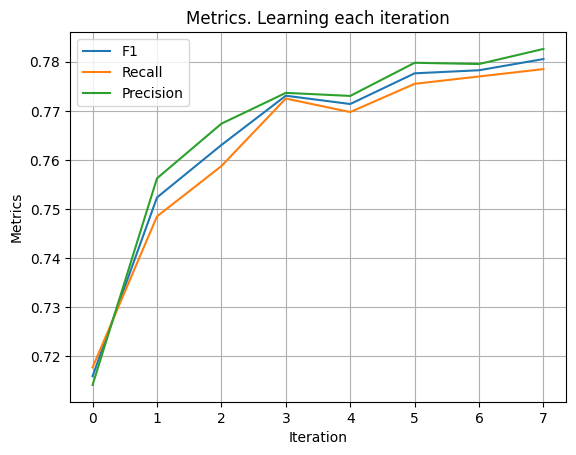

In [9]:
plt.plot(F1_list, label = 'F1')
plt.plot(recall_list, label = 'Recall')
plt.plot(precision_list, label = 'Precision')
plt.title('Metrics. Learning each iteration')
plt.xlabel('Iteration')
plt.ylabel('Metrics')
plt.legend()
plt.grid()

In [4]:
# lernong classification
def calc_classification_metric(proton_st: np.array, photon_st: np.array, ax: plt.Axes):
    X = np.vstack([proton_st, photon_st])
    y = np.array([0] * len(proton_st) + [1] * len(photon_st))
    # Разделение на тренировочную и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        stratify=y,
        random_state=42
    )

    # Создание и обучение CatBoost классификатора
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.1,
        depth=6,
        verbose=100,
        early_stopping_rounds=50,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        plot=True
    )

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # Оценка модели
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    # ax.text(0.5, 0.5, classification_report(y_test, y_pred), fontsize=14, ha='center', va='center')
    # ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
    # print("\nConfusion Matrix:")
    # print(y_test, y_pred)
    # print(confusion_matrix(y_test, y_pred))
    f1_score_ = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return f1_score_,recall, precision, ax, model 
Classificators = []
F1_list = []
recall_list = []
precision_list = []
num_iter = len(all_emb['proton'].keys())
# num_iter = 1
# fig, axs = plt.subplots(num_iter,1, figsize=(5,6*num_iter), sharex=True)
# for i in tqdm_notebook(range(num_iter)):
for i in tqdm_notebook(range(1, num_iter)):
    proton_st = all_emb['proton'][i][:20000] - all_emb['proton'][0][:20000]
    photon_st = all_emb['photon'][i][:20000]- all_emb['photon'][0][:20000]
    ax = None#axs[i]
    f1_score_,recall, precision, ax, model  = calc_classification_metric(proton_st, photon_st, ax)
    print(f'f1_score in iteration {i}: {f1_score_}')
    Classificators.append(model)
    F1_list.append(f1_score_)
    recall_list.append(recall)
    precision_list.append(precision)

/tmp/ipykernel_59160/818435462.py:53: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(1, num_iter)):


  0%|          | 0/8 [00:00<?, ?it/s]

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6798180	test: 0.6804238	best: 0.6804238 (0)	total: 53.8ms	remaining: 2m 41s
100:	learn: 0.5452785	test: 0.5705947	best: 0.5705947 (100)	total: 761ms	remaining: 21.8s
200:	learn: 0.5067238	test: 0.5573888	best: 0.5573888 (200)	total: 1.56s	remaining: 21.8s
300:	learn: 0.4758341	test: 0.5520790	best: 0.5520790 (300)	total: 2.2s	remaining: 19.7s
400:	learn: 0.4503682	test: 0.5492456	best: 0.5492456 (400)	total: 2.89s	remaining: 18.8s
500:	learn: 0.4271472	test: 0.5471396	best: 0.5470555 (495)	total: 3.58s	remaining: 17.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5470555436
bestIteration = 495

Shrink model to first 496 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      4000
           1       0.71      0.72      0.72      4000

    accuracy                           0.72      8000
   macro avg       0.72      0.72      0.72      8000
weighted avg       0.72      0

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

...

0:	learn: 0.6678889	test: 0.6679911	best: 0.6679911 (0)	total: 13.2ms	remaining: 39.6s
100:	learn: 0.4717116	test: 0.4956057	best: 0.4956057 (100)	total: 671ms	remaining: 19.3s
200:	learn: 0.4317143	test: 0.4833734	best: 0.4833477 (199)	total: 1.29s	remaining: 17.9s
300:	learn: 0.4005351	test: 0.4777436	best: 0.4777436 (300)	total: 1.93s	remaining: 17.3s
400:	learn: 0.3751675	test: 0.4762437	best: 0.4761504 (367)	total: 2.56s	remaining: 16.6s
500:	learn: 0.3534599	test: 0.4757748	best: 0.4755893 (494)	total: 3.23s	remaining: 16.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4754427024
bestIteration = 539

Shrink model to first 540 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6677124	test: 0.6682580	best: 0.6682580 (0)	total: 12.1ms	remaining: 36.3s
100:	learn: 0.4721863	test: 0.4965123	best: 0.4965123 (100)	total: 666ms	remaining: 19.1s
200:	learn: 0.4318796	test: 0.4835957	best: 0.4835957 (200)	total: 1.31s	remaining: 18.2s
300:	learn: 0.4013558	test: 0.4785210	best: 0.4785052 (299)	total: 1.95s	remaining: 17.5s
400:	learn: 0.3749423	test: 0.4774193	best: 0.4771344 (388)	total: 2.59s	remaining: 16.8s
500:	learn: 0.3528818	test: 0.4764061	best: 0.4761711 (475)	total: 3.3s	remaining: 16.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4761710888
bestIteration = 475

Shrink model to first 476 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6675358	test: 0.6680786	best: 0.6680786 (0)	total: 13.6ms	remaining: 40.7s
100:	learn: 0.4699941	test: 0.4922609	best: 0.4922609 (100)	total: 728ms	remaining: 20.9s
200:	learn: 0.4296081	test: 0.4790164	best: 0.4790164 (200)	total: 1.42s	remaining: 19.8s
300:	learn: 0.3995102	test: 0.4733428	best: 0.4733428 (300)	total: 2.09s	remaining: 18.8s
400:	learn: 0.3741514	test: 0.4709448	best: 0.4707951 (394)	total: 2.78s	remaining: 18s
500:	learn: 0.3514400	test: 0.4701346	best: 0.4698973 (480)	total: 3.46s	remaining: 17.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4697309599
bestIteration = 520

Shrink model to first 521 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4000
           1       0.78      0.78      0.78      4000

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.7

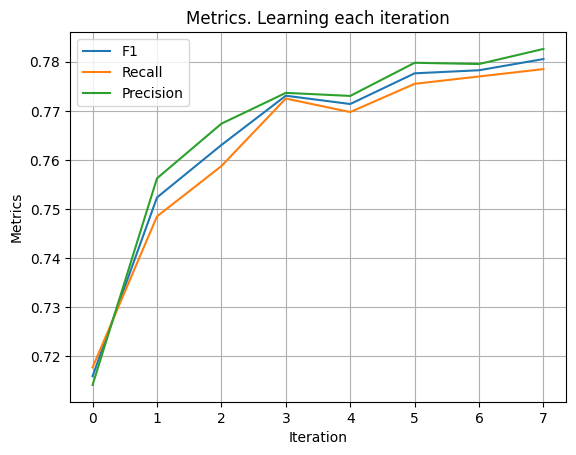

In [5]:
plt.plot(F1_list, label = 'F1')
plt.plot(recall_list, label = 'Recall')
plt.plot(precision_list, label = 'Precision')
plt.title('Metrics. Learning each iteration')
plt.xlabel('Iteration')
plt.ylabel('Metrics')
plt.legend()
plt.grid()

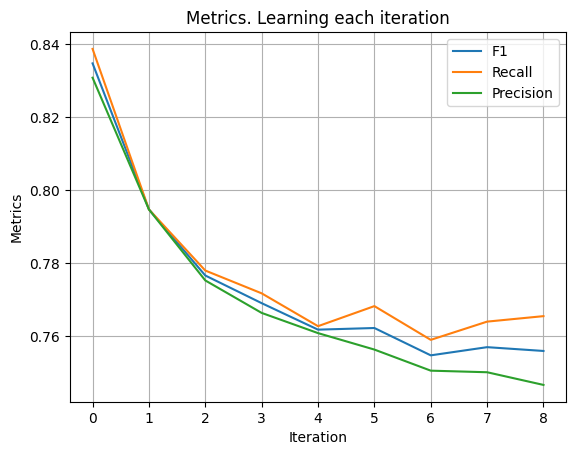

In [ ]:

plt.plot(F1_list, label = 'F1')
plt.plot(recall_list, label = 'Recall')
plt.plot(precision_list, label = 'Precision')
plt.title('Metrics. Learning each iteration')
plt.xlabel('Iteration')
plt.ylabel('Metrics')
plt.legend()
plt.grid()

In [6]:
model =  Classificators[0]
F1_list_2 = []
recall_list_2 = []
precision_list_2 = []

# return f1_score_, ax, model 
num_iter = len(all_emb['proton'].keys())
for i in tqdm_notebook(range(num_iter)):
    proton_st = all_emb['proton'][i]
    photon_st = all_emb['photon'][i]
    
    X = np.vstack([proton_st, photon_st])
    y = np.array([0] * len(proton_st) + [1] * len(photon_st))
    # Разделение на тренировочную и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        stratify=y,
        random_state=42
    )
    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    f1_score_ = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    F1_list_2.append(f1_score_)
    recall_list_2.append(recall)
    precision_list_2.append(precision)

/tmp/ipykernel_2571/774920953.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/9 [00:00<?, ?it/s]

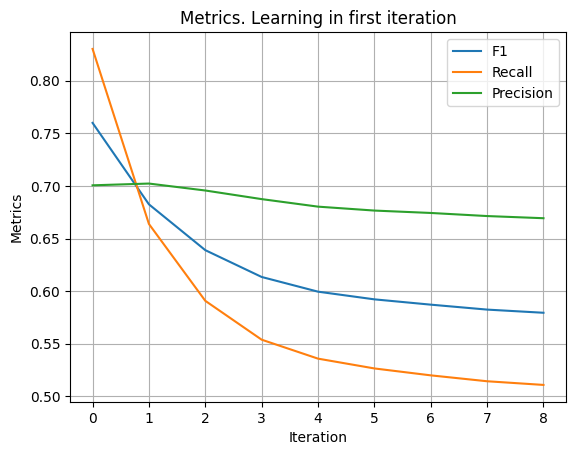

In [7]:
plt.plot(F1_list_2, label = 'F1')
plt.plot(recall_list_2, label = 'Recall')
plt.plot(precision_list_2, label = 'Precision')
plt.title('Metrics. Learning in first iteration')
plt.xlabel('Iteration')
plt.ylabel('Metrics')
plt.legend()
plt.grid()

In [24]:

proton_st = np.concatenate([all_emb['proton'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)

/tmp/ipykernel_63631/3906084815.py:1: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  proton_st = np.concatenate([all_emb['proton'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)


  0%|          | 0/9 [00:00<?, ?it/s]

In [27]:

proton_st = np.concatenate([all_emb['proton'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)
photon_st = np.concatenate([all_emb['photon'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)
ax = None#axs[i]
f1_score_,recall, precision, ax, model  = calc_classification_metric(proton_st, photon_st, ax)
print(f'f1_score in iteration {i}: {f1_score_}')
print('recall', recall)
print('precision', precision)
# Classificators.append(model)
# F1_list.append(f1_score_)
# recall_list.append(recall)
# precision_list.append(precision)


/tmp/ipykernel_63631/1630456831.py:1: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  proton_st = np.concatenate([all_emb['proton'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)


  0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_63631/1630456831.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  photon_st = np.concatenate([all_emb['photon'][i][:20000] for i in tqdm_notebook(range(num_iter))], axis=1)


  0%|          | 0/9 [00:00<?, ?it/s]

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6590199	test: 0.6588910	best: 0.6588910 (0)	total: 32.8ms	remaining: 1m 38s
100:	learn: 0.3697946	test: 0.3862132	best: 0.3862132 (100)	total: 2.01s	remaining: 57.7s
200:	learn: 0.3183493	test: 0.3665118	best: 0.3665111 (199)	total: 3.91s	remaining: 54.4s
300:	learn: 0.2823947	test: 0.3610034	best: 0.3610034 (300)	total: 5.83s	remaining: 52.2s
400:	learn: 0.2539142	test: 0.3581010	best: 0.3581010 (400)	total: 7.76s	remaining: 50.3s
500:	learn: 0.2293313	test: 0.3565892	best: 0.3565452 (477)	total: 9.69s	remaining: 48.3s
600:	learn: 0.2082872	test: 0.3554023	best: 0.3552459 (577)	total: 11.6s	remaining: 46.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.35488663
bestIteration = 639

Shrink model to first 640 iterations.
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4000
           1       0.84      0.85      0.85      4000

    accuracy                           0.84      

/tmp/ipykernel_25143/863018389.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/2 [00:00<?, ?it/s]

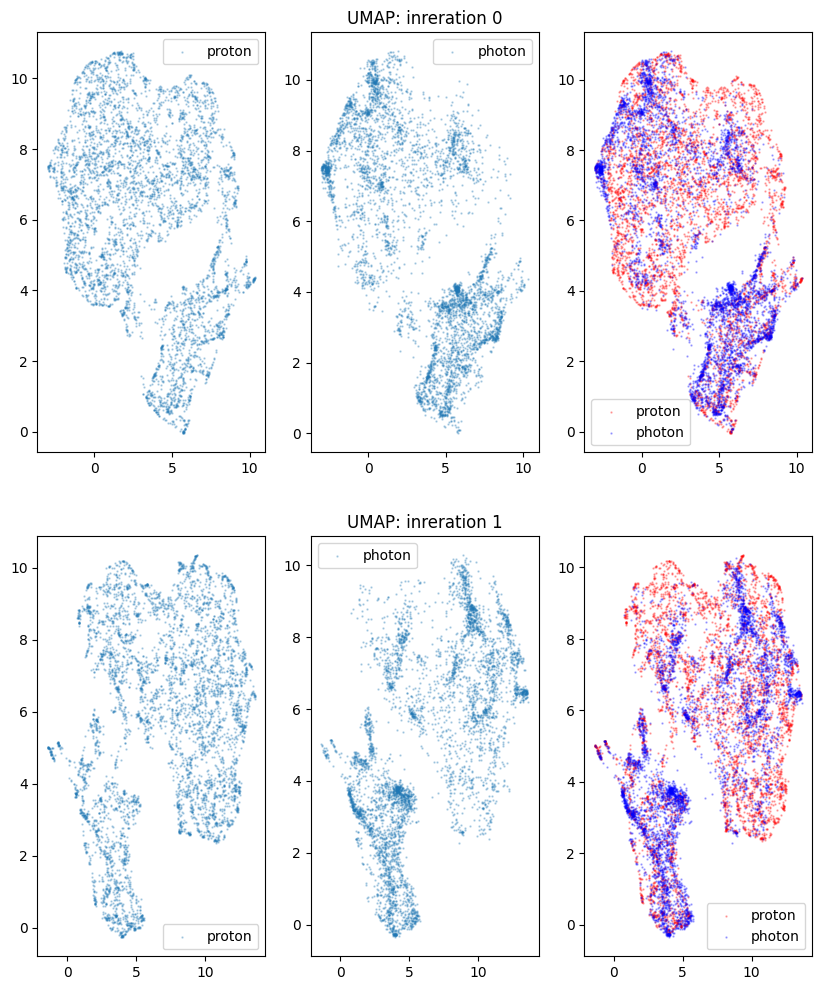

In [4]:
num_iter = len(all_emb['proton'].keys())
num_iter = 2
fig, axs = plt.subplots(num_iter,3, figsize=(10,6*num_iter))
for i in tqdm_notebook(range(num_iter)):
    ax_row = axs[i]
    proton_st = all_emb['proton'][i][:5000]
    photon_st = all_emb['photon'][i][:5000]

    all_st= np.concatenate([proton_st, photon_st], axis=0) 
    reducer = umap.UMAP()
    manifold = reducer.fit(proton_st)
    X_pr = manifold.transform(proton_st)
    X_ph = manifold.transform(photon_st)
    X_reduced = manifold.transform(all_st)
    names = ['proton', 'photon']
    # ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=lable, cmap='viridis', alpha=0.7, label=names)
    # ax.legend()
    if not(ax_row is None):
        ax_1,ax_2, ax_3  = ax_row
        ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0])
        ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1])
        ax2 = (ax_1,ax_2)
        ax_1.legend()
        ax_2.legend()
        ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color = 'r')
        ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color = 'b')
        ax_3.legend()

        ax_2.set_title(f'UMAP: inreration {i}')


/tmp/ipykernel_63631/4203920003.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/9 [00:00<?, ?it/s]

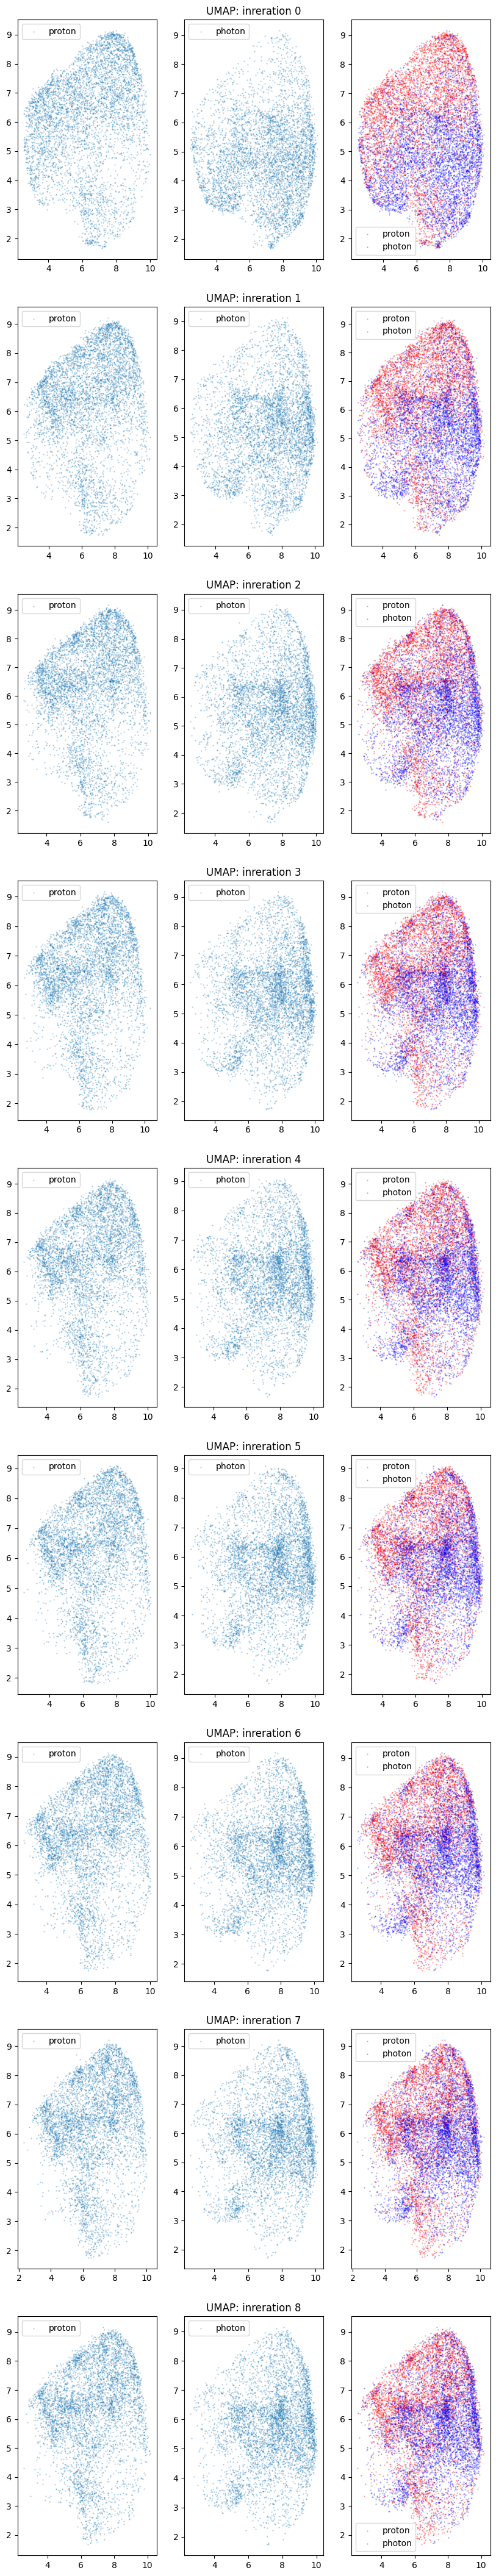

In [19]:
num_iter = len(all_emb['proton'].keys())
# Train umap on oigina
proton_st = all_emb['proton'][0][:5000]
photon_st = all_emb['photon'][0][:5000]

all_st= np.concatenate([proton_st, photon_st], axis=0) 
reducer = umap.UMAP()
manifold = reducer.fit(all_st)


fig, axs = plt.subplots(num_iter,3, figsize=(10,6*num_iter))
for i in tqdm_notebook(range(num_iter)):
    ax_row = axs[i]
    proton_st = all_emb['proton'][i][:5000]
    photon_st = all_emb['photon'][i][:5000]
    X_pr = manifold.transform(proton_st)
    X_ph = manifold.transform(photon_st)
    X_reduced = manifold.transform(all_st)
    names = ['proton', 'photon']
    if not(ax_row is None):
        ax_1,ax_2, ax_3  = ax_row
        ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0])
        ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1])
        ax2 = (ax_1,ax_2)
        ax_1.legend()
        ax_2.legend()
        ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color = 'r')
        ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color = 'b')
        ax_3.legend()

        ax_2.set_title(f'UMAP: inreration {i}')

/tmp/ipykernel_63631/3215215241.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/9 [00:00<?, ?it/s]

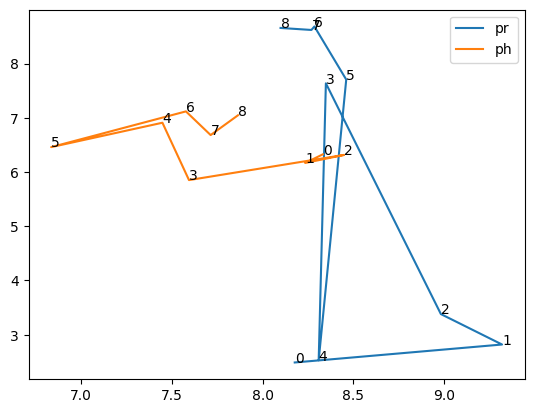

In [20]:
pr_list = [[],[]]
ph_list = [[],[]]
k=106
for i in tqdm_notebook(range(num_iter)):
    ax_row = axs[i]
    proton_st = all_emb['proton'][i][k:k+1]
    photon_st = all_emb['photon'][i][k:k+1]
    X_pr = manifold.transform(proton_st)
    X_ph = manifold.transform(photon_st)
    X_reduced = manifold.transform(all_st)

    pr_list[0].append(X_pr[0][0])
    pr_list[1].append(X_pr[0][1])

    ph_list[0].append(X_ph[0][0])
    ph_list[1].append(X_ph[0][1])
plt.plot(pr_list[0], pr_list[1], label = 'pr')
for i in range(num_iter):
    plt.text(pr_list[0][i], pr_list[1][i], str(i))
plt.plot(ph_list[0], ph_list[1], label= 'ph')
for i in range(num_iter):
    plt.text(ph_list[0][i], ph_list[1][i], str(i))
plt.legend()
    # names = ['proton', 'photon']
    # if not(ax_row is None):
    #     ax_1,ax_2, ax_3  = ax_row
    #     ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0])
    #     ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1])
    #     ax2 = (ax_1,ax_2)
    #     ax_1.legend()
    #     ax_2.legend()
    #     ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color = 'r')
    #     ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color = 'b')
    #     ax_3.legend()

    #     ax_2.set_title(f'UMAP: inreration {i}')

/tmp/ipykernel_25143/3852059784.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/1 [00:00<?, ?it/s]

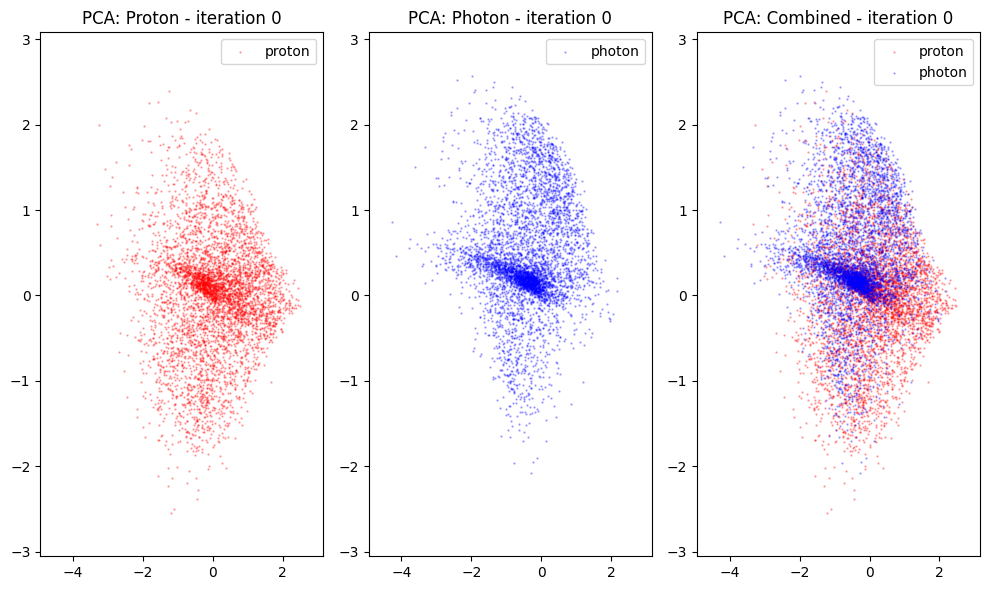

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

num_iter = len(all_emb['proton'].keys())
num_iter = 1
fig, axs = plt.subplots(num_iter, 3, figsize=(10, 6*num_iter))

for i in tqdm_notebook(range(num_iter)):
    ax_row = axs[i] if num_iter > 1 else axs  # Обработка случая с одной итерацией
    proton_st = all_emb['proton'][i][:5000]
    photon_st = all_emb['photon'][i][:5000]
    
    all_st = np.concatenate([proton_st, photon_st], axis=0)
    
    # PCA с 2 компонентами
    reducer = PCA(n_components=2, random_state=42)
    reducer = reducer.fit(proton_st)
    X_reduced = reducer.transform(all_st)
    
    # Разделяем обратно на proton и photon
    X_pr = X_reduced[:len(proton_st)]
    X_ph = X_reduced[len(proton_st):]
    
    names = ['proton', 'photon']
    
    if not (ax_row is None):
        ax_1, ax_2, ax_3 = ax_row
        
        # Только proton
        ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color='r')
        ax_1.legend()
        ax_1.set_title(f'PCA: Proton - iteration {i}')
        
        # Только photon
        ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color='b')
        ax_2.legend()
        ax_2.set_title(f'PCA: Photon - iteration {i}')
        
        # Совместный график
        ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color='r')
        ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color='b')
        ax_3.legend()
        ax_3.set_title(f'PCA: Combined - iteration {i}')
        
        # Настраиваем одинаковые пределы осей для всех трех графиков в строке
        x_min = min(X_pr[:, 0].min(), X_ph[:, 0].min())
        x_max = max(X_pr[:, 0].max(), X_ph[:, 0].max())
        y_min = min(X_pr[:, 1].min(), X_ph[:, 1].min())
        y_max = max(X_pr[:, 1].max(), X_ph[:, 1].max())
        
        # Добавляем небольшие отступы
        x_margin = (x_max - x_min) * 0.1
        y_margin = (y_max - y_min) * 0.1
        
        ax_1.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_1.set_ylim(y_min - y_margin, y_max + y_margin)
        ax_2.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_2.set_ylim(y_min - y_margin, y_max + y_margin)
        ax_3.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_3.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()

/tmp/ipykernel_754/3157083149.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(num_iter)):


  0%|          | 0/1 [00:00<?, ?it/s]

/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


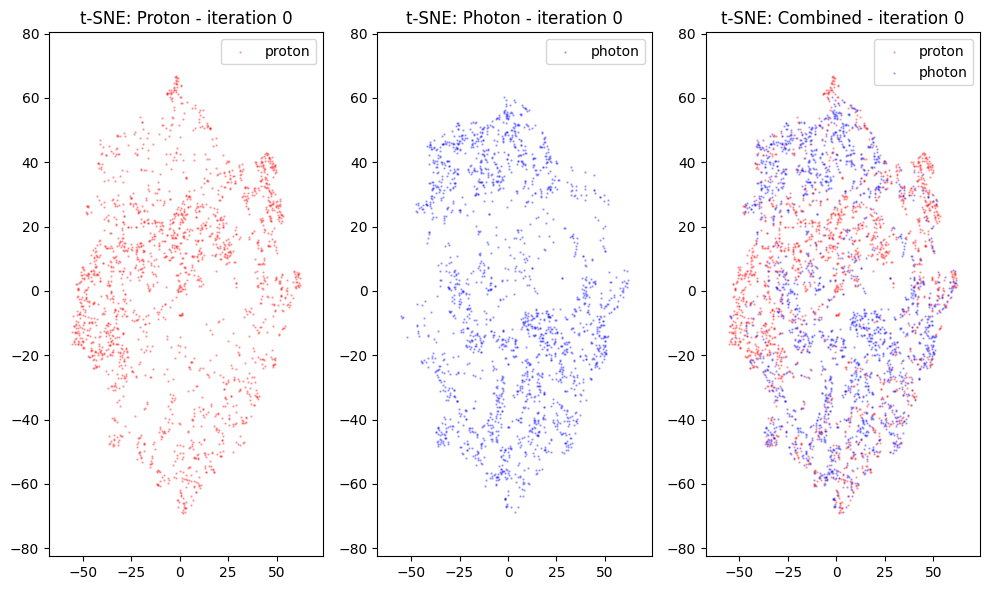

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

num_iter = len(all_emb['proton'].keys())
num_iter = 1
fig, axs = plt.subplots(num_iter, 3, figsize=(10, 6*num_iter))

for i in tqdm_notebook(range(num_iter)):
    ax_row = axs[i] if num_iter > 1 else axs  # Обработка случая с одной итерацией
    proton_st = all_emb['proton'][i][:2000]
    photon_st = all_emb['photon'][i][:2000]
    
    all_st = np.concatenate([proton_st, photon_st], axis=0)
    
    # t-SNE с 2 компонентами
    # Примечание: t-SNE медленный, для 5000+5000 точек может потребоваться время
    reducer = TSNE(n_components=2, 
                   random_state=42,
                   perplexity=30,  # Можете настроить под ваши данные
                   n_iter=1000,
                   init='pca',
                   learning_rate='auto')
    
    X_reduced = reducer.fit_transform(all_st)
    
    # Разделяем обратно на proton и photon
    X_pr = X_reduced[:len(proton_st)]
    X_ph = X_reduced[len(proton_st):]
    
    names = ['proton', 'photon']
    
    if not (ax_row is None):
        ax_1, ax_2, ax_3 = ax_row
        
        # Только proton
        ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color='r')
        ax_1.legend()
        ax_1.set_title(f't-SNE: Proton - iteration {i}')
        
        # Только photon
        ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color='b')
        ax_2.legend()
        ax_2.set_title(f't-SNE: Photon - iteration {i}')
        
        # Совместный график
        ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label=names[0], color='r')
        ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label=names[1], color='b')
        ax_3.legend()
        ax_3.set_title(f't-SNE: Combined - iteration {i}')
        
        # Настраиваем одинаковые пределы осей для всех трех графиков в строке
        x_min = min(X_pr[:, 0].min(), X_ph[:, 0].min())
        x_max = max(X_pr[:, 0].max(), X_ph[:, 0].max())
        y_min = min(X_pr[:, 1].min(), X_ph[:, 1].min())
        y_max = max(X_pr[:, 1].max(), X_ph[:, 1].max())
        
        # Добавляем небольшие отступы
        x_margin = (x_max - x_min) * 0.1
        y_margin = (y_max - y_min) * 0.1
        
        ax_1.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_1.set_ylim(y_min - y_margin, y_max + y_margin)
        ax_2.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_2.set_ylim(y_min - y_margin, y_max + y_margin)
        ax_3.set_xlim(x_min - x_margin, x_max + x_margin)
        ax_3.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()